Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 141MB/s]


Step 0 | Loss: 3.44
Step 50 | Loss: 0.70
Step 100 | Loss: 0.58
Step 150 | Loss: 0.57
Step 200 | Loss: 0.57
Step 250 | Loss: 0.57
Step 300 | Loss: 0.57
Step 350 | Loss: 0.59

Style Transfer Completed!


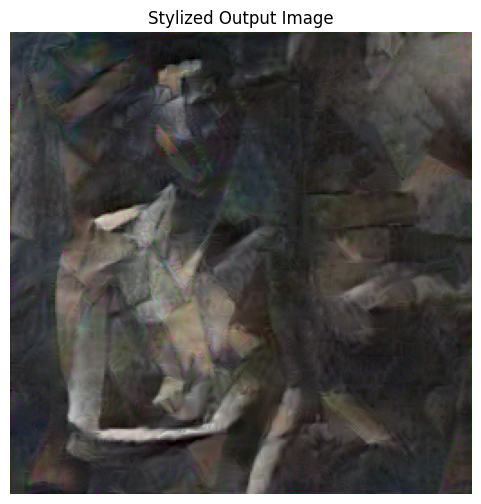

In [2]:
# =====================================
# Neural Style Transfer (Improved)
# =====================================

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------------
# Load Content and Style Images
# -------------------------------------

content_url = "https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"
style_url = "https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg"

content_img = Image.open(BytesIO(requests.get(content_url).content)).convert("RGB")
style_img = Image.open(BytesIO(requests.get(style_url).content)).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

content = transform(content_img).unsqueeze(0).to(device)
style = transform(style_img).unsqueeze(0).to(device)

# -------------------------------------
# Load Pretrained VGG19
# -------------------------------------

vgg = vgg19(weights=VGG19_Weights.DEFAULT).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad_(False)

# -------------------------------------
# Layers used for style & content
# -------------------------------------

content_layer = '21'

style_layers = ['0','5','10','19','28']

# -------------------------------------
# Feature Extraction
# -------------------------------------

def get_features(x, model):

    features = {}

    for name, layer in model._modules.items():

        x = layer(x)

        if name == content_layer:
            features['content'] = x

        if name in style_layers:
            features[name] = x

    return features

# -------------------------------------
# Gram Matrix (Style Representation)
# -------------------------------------

def gram_matrix(tensor):

    b,c,h,w = tensor.size()

    tensor = tensor.view(c, h*w)

    gram = torch.mm(tensor, tensor.t())

    return gram/(c*h*w)

# -------------------------------------
# Extract Features
# -------------------------------------

content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_layers}

# -------------------------------------
# Generated Image
# -------------------------------------

generated = content.clone().requires_grad_(True)

optimizer = torch.optim.Adam([generated], lr=0.02)

# weights
content_weight = 1
style_weight = 1e6

# -------------------------------------
# Optimization Loop
# -------------------------------------

steps = 400

for step in range(steps):

    gen_features = get_features(generated, vgg)

    # Content Loss
    content_loss = torch.mean(
        (gen_features["content"] - content_features["content"])**2
    )

    # Style Loss
    style_loss = 0

    for layer in style_layers:

        gen_feature = gen_features[layer]
        gen_gram = gram_matrix(gen_feature)

        style_gram = style_grams[layer]

        style_loss += torch.mean((gen_gram - style_gram)**2)

    total_loss = content_weight*content_loss + style_weight*style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # clamp image values
    generated.data.clamp_(0,1)

    if step % 50 == 0:
        print(f"Step {step} | Loss: {total_loss.item():.2f}")

print("\nStyle Transfer Completed!")

# -------------------------------------
# Show Final Output
# -------------------------------------

output = generated.detach().cpu().squeeze().permute(1,2,0)

plt.figure(figsize=(6,6))
plt.imshow(output)
plt.title("Stylized Output Image")
plt.axis("off")
plt.show()